# **Melbourne Pedestrian Forecasting**

# Setup

In [1]:
!pip install google-cloud-bigquery pandas-gbq prophet xgboost scikit-learn mlflow dagshub pyarrow db-dtypes -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from google.cloud import bigquery
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from xgboost import XGBRegressor

PROJECT_ID = "melbourne-pedestrian-pipeline"
client = bigquery.Client(project=PROJECT_ID)

# Load Data BigQuery

In [4]:
query = """
    SELECT *
    FROM `melbourne-pedestrian-pipeline.staging.mart_pedestrian_hourly`
    ORDER BY sensing_datetime
"""

df = client.query(query).to_dataframe()
df['sensing_date'] = pd.to_datetime(df['sensing_date'].astype(str))
df['sensing_datetime'] = pd.to_datetime(df['sensing_datetime'].astype(str))
df['pedestrian_count'] = df['pedestrian_count'].astype(float)

print(f"Shape: {df.shape}")
print(f"Date range: {df['sensing_date'].min()} to {df['sensing_date'].max()}")
print(f"Unique sensors: {df['sensor_name'].nunique()}")
print(f"Weather coverage: {df['temperature_c'].notna().sum():,} rows")

Shape: (1593424, 25)
Date range: 2024-05-30 00:00:00 to 2026-05-29 00:00:00
Unique sensors: 97
Weather coverage: 1,579,557 rows


# EDA

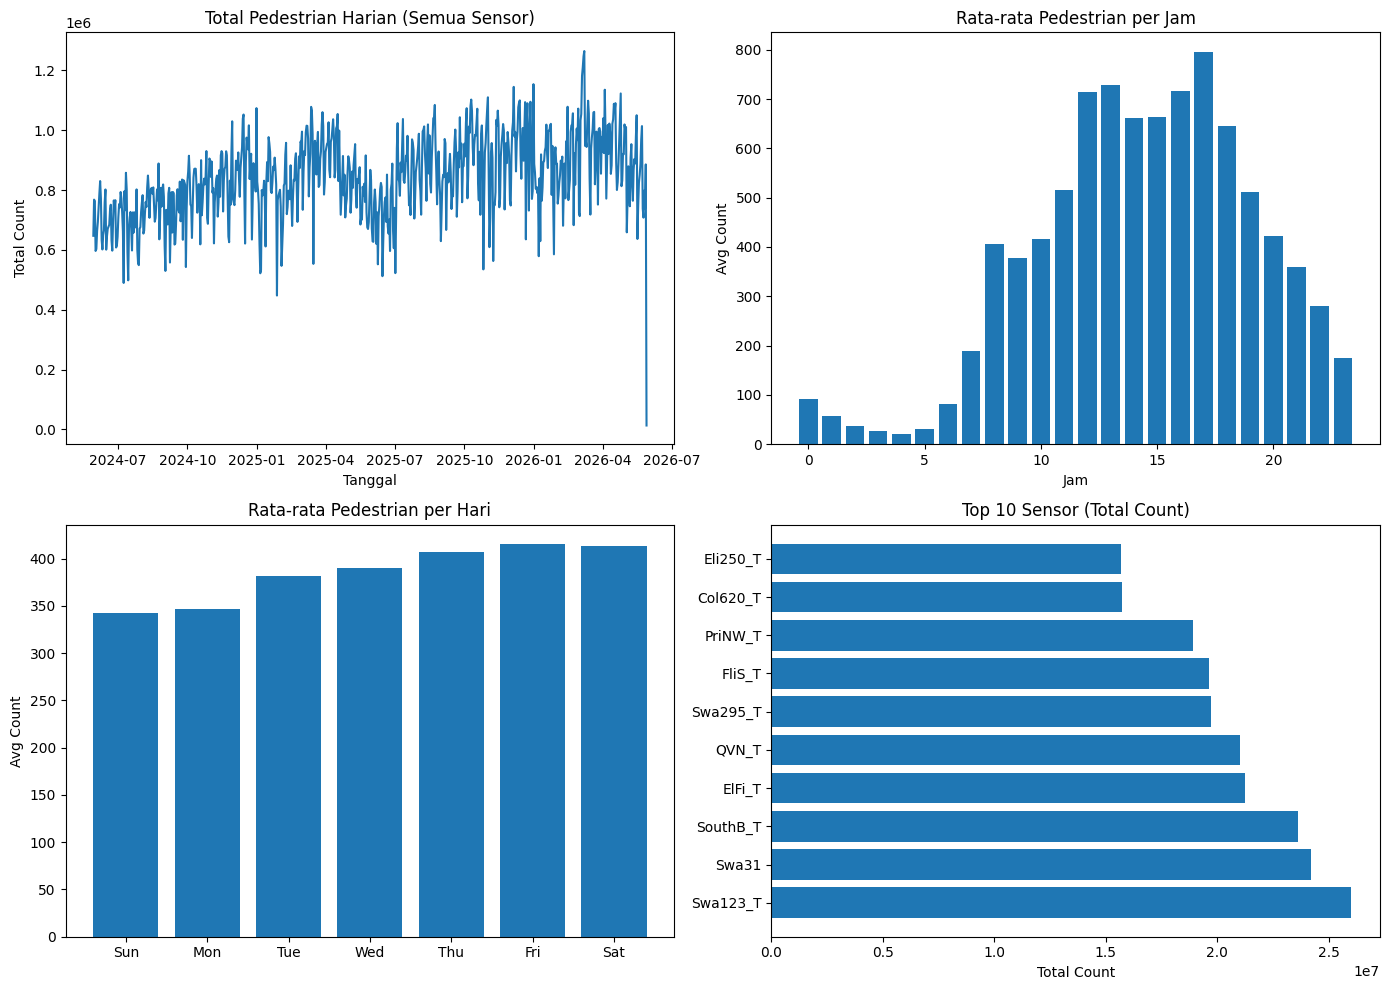

count    1.593424e+06
mean     3.853295e+02
std      5.670895e+02
min      0.000000e+00
25%      3.800000e+01
50%      1.600000e+02
75%      4.870000e+02
max      1.111300e+04
Name: pedestrian_count, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

daily = df.groupby('sensing_date')['pedestrian_count'].sum().reset_index()
axes[0,0].plot(daily['sensing_date'], daily['pedestrian_count'])
axes[0,0].set_title('Total Pedestrian Harian (Semua Sensor)')
axes[0,0].set_xlabel('Tanggal')
axes[0,0].set_ylabel('Total Count')

hourly_avg = df.groupby('hour_of_day')['pedestrian_count'].mean()
axes[0,1].bar(hourly_avg.index, hourly_avg.values)
axes[0,1].set_title('Rata-rata Pedestrian per Jam')
axes[0,1].set_xlabel('Jam')
axes[0,1].set_ylabel('Avg Count')

dow_avg = df.groupby('day_of_week')['pedestrian_count'].mean()
dow_labels = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
axes[1,0].bar(dow_labels, dow_avg.values)
axes[1,0].set_title('Rata-rata Pedestrian per Hari')
axes[1,0].set_ylabel('Avg Count')

top_sensors = df.groupby('sensor_name')['pedestrian_count'].sum().nlargest(10)
axes[1,1].barh(top_sensors.index, top_sensors.values)
axes[1,1].set_title('Top 10 Sensor (Total Count)')
axes[1,1].set_xlabel('Total Count')

plt.tight_layout()
plt.show()
print(df['pedestrian_count'].describe())

# Data Preparation (SouthB_T Riverside)

In [6]:
SENSOR = 'SouthB_T'
LOCATION_ID = 212

df_sensor = df[
    (df['sensor_name'] == SENSOR) &
    (df['location_id'] == LOCATION_ID)
].copy().sort_values('sensing_datetime').reset_index(drop=True)

split_idx = int(len(df_sensor) * 0.8)
df_train = df_sensor.iloc[:split_idx].copy()
df_test  = df_sensor.iloc[split_idx:].copy()

print(f"Shape: {df_sensor.shape}")
print(f"Train: {len(df_train):,} | {df_train['sensing_datetime'].min().date()} to {df_train['sensing_datetime'].max().date()}")
print(f"Test:  {len(df_test):,}  | {df_test['sensing_datetime'].min().date()} to {df_test['sensing_datetime'].max().date()}")

Shape: (17496, 25)
Train: 13,996 | 2024-05-30 to 2026-01-03
Test:  3,500  | 2026-01-03 to 2026-05-29


# Model 1: Prophet

In [7]:
df_prophet_train = df_train[['sensing_datetime', 'pedestrian_count']].rename(
    columns={'sensing_datetime': 'ds', 'pedestrian_count': 'y'}
)
df_prophet_train['ds'] = df_prophet_train['ds'].dt.tz_localize(None)

df_prophet_test = df_test[['sensing_datetime', 'pedestrian_count']].rename(
    columns={'sensing_datetime': 'ds', 'pedestrian_count': 'y'}
)
df_prophet_test['ds'] = df_prophet_test['ds'].dt.tz_localize(None)

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative'
)
model_prophet.fit(df_prophet_train)

future = model_prophet.make_future_dataframe(periods=len(df_prophet_test), freq='h')
forecast = model_prophet.predict(future)

y_pred_prophet = np.maximum(forecast.tail(len(df_prophet_test))['yhat'].values, 0)
y_true_prophet = df_prophet_test['y'].values

mae_prophet  = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))
mape_prophet = np.mean(np.abs((y_true_prophet - y_pred_prophet) / (y_true_prophet + 1))) * 100

print(f"Prophet — MAE: {mae_prophet:.2f} | RMSE: {rmse_prophet:.2f} | MAPE: {mape_prophet:.2f}%")

Prophet — MAE: 445.80 | RMSE: 593.85 | MAPE: 186.32%


# Model 2: XGBoost

In [8]:
FEATURES = [
    'hour', 'day_of_week', 'month', 'quarter',
    'is_weekend', 'is_public_holiday',
    'temperature_c', 'precipitation_mm', 'windspeed_ms', 'humidity_pct',
    'lag_1h', 'lag_24h', 'lag_168h',
    'rolling_mean_24h', 'rolling_mean_168h'
]

def create_features(df):
    df = df.copy()
    df['hour'] = df['sensing_datetime'].dt.hour
    df['day_of_week'] = df['sensing_datetime'].dt.dayofweek
    df['month'] = df['sensing_datetime'].dt.month
    df['quarter'] = df['sensing_datetime'].dt.quarter
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_public_holiday'] = df['is_public_holiday'].astype(int)
    for col in ['temperature_c', 'precipitation_mm', 'windspeed_ms', 'humidity_pct']:
        df[col] = df[col].fillna(df[col].median())
    df = df.sort_values('sensing_datetime').reset_index(drop=True)
    df['lag_1h']   = df['pedestrian_count'].shift(1)
    df['lag_24h']  = df['pedestrian_count'].shift(24)
    df['lag_168h'] = df['pedestrian_count'].shift(168)
    df['rolling_mean_24h']  = df['pedestrian_count'].shift(1).rolling(24).mean()
    df['rolling_mean_168h'] = df['pedestrian_count'].shift(1).rolling(168).mean()
    return df

df_feat = create_features(df_sensor)
df_feat = df_feat.dropna(subset=FEATURES + ['pedestrian_count']).reset_index(drop=True)

split_idx = int(len(df_feat) * 0.8)
df_xgb_train = df_feat.iloc[:split_idx]
df_xgb_test  = df_feat.iloc[split_idx:]

X_train, y_train = df_xgb_train[FEATURES], df_xgb_train['pedestrian_count']
X_test,  y_test  = df_xgb_test[FEATURES],  df_xgb_test['pedestrian_count']

model_xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred_xgb  = np.maximum(model_xgb.predict(X_test), 0)
y_test_vals = y_test.values

mae_xgb  = mean_absolute_error(y_test_vals, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_vals, y_pred_xgb))
mape_xgb = np.mean(np.abs((y_test_vals - y_pred_xgb) / (y_test_vals + 1))) * 100

print(f"XGBoost — MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | MAPE: {mape_xgb:.2f}%")

[0]	validation_0-rmse:614.19813
[100]	validation_0-rmse:155.27682
[200]	validation_0-rmse:149.09306
[300]	validation_0-rmse:147.01604
[400]	validation_0-rmse:146.27291
[499]	validation_0-rmse:145.93686
XGBoost — MAE: 92.33 | RMSE: 145.94 | MAPE: 26.54%


# Evaluation & Comparation

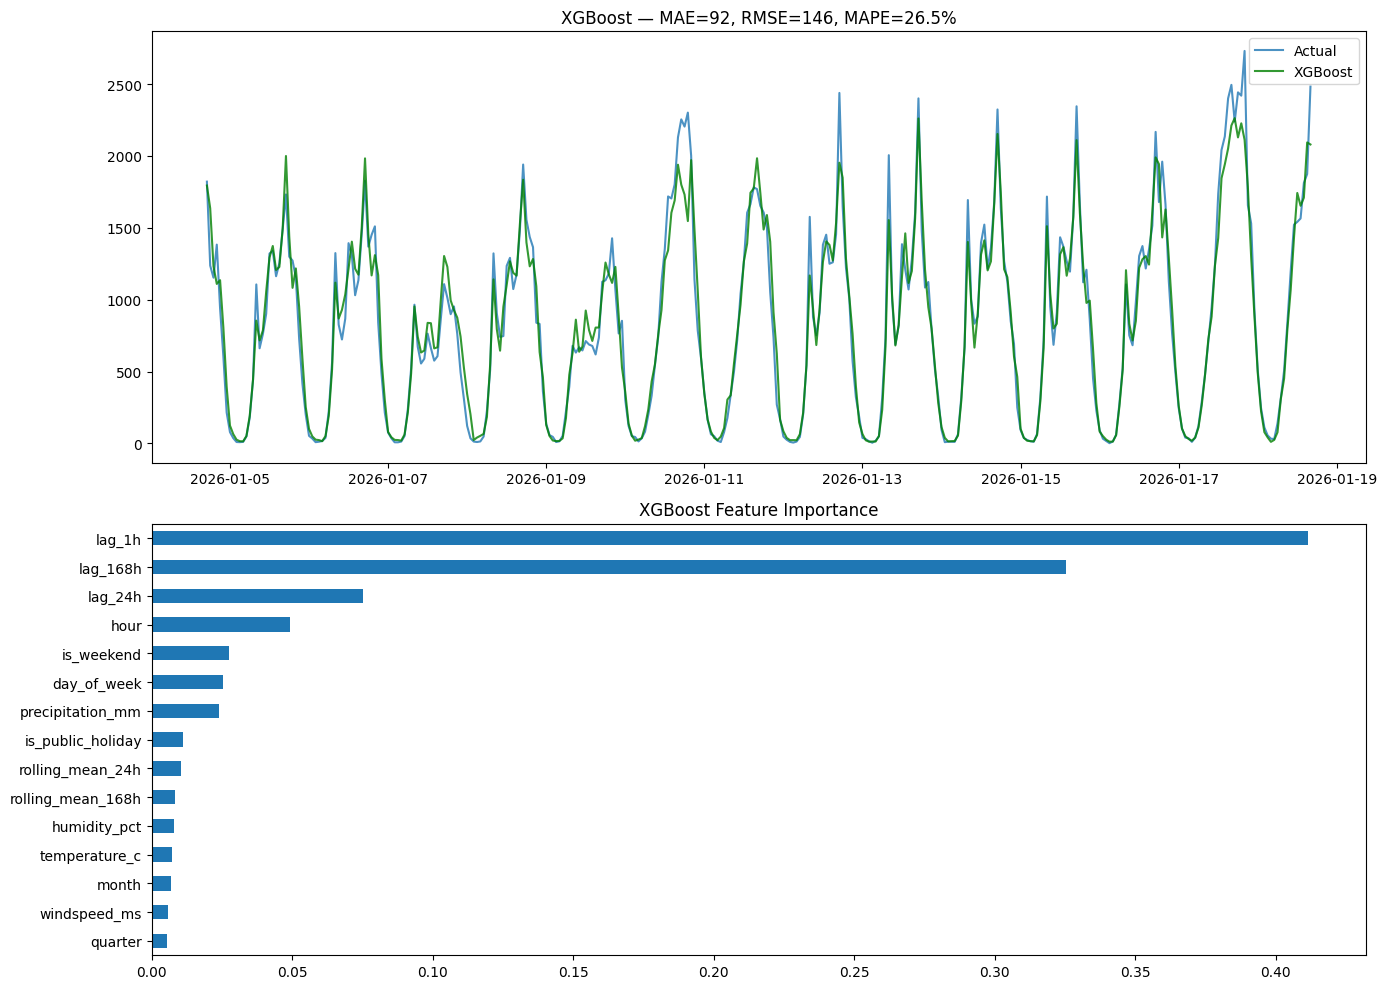

MODEL COMPARISON — SouthB_T (Riverside)
Model             MAE     RMSE     MAPE
Prophet         445.8    593.8   186.3%
XGBoost          92.3    145.9    26.5%

XGBoost lebih baik 4.8x dari Prophet


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
n_plot = 24 * 14

axes[0].plot(df_xgb_test['sensing_datetime'].values[:n_plot], y_test_vals[:n_plot], label='Actual', alpha=0.8)
axes[0].plot(df_xgb_test['sensing_datetime'].values[:n_plot], y_pred_xgb[:n_plot], label='XGBoost', alpha=0.8, color='green')
axes[0].set_title(f'XGBoost — MAE={mae_xgb:.0f}, RMSE={rmse_xgb:.0f}, MAPE={mape_xgb:.1f}%')
axes[0].legend()

feat_imp = pd.Series(model_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1])
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

print('=' * 40)
print('MODEL COMPARISON — SouthB_T (Riverside)')
print('=' * 40)
print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"{'Prophet':<12} {mae_prophet:>8.1f} {rmse_prophet:>8.1f} {mape_prophet:>7.1f}%")
print(f"{'XGBoost':<12} {mae_xgb:>8.1f} {rmse_xgb:>8.1f} {mape_xgb:>7.1f}%")
print(f"\nXGBoost lebih baik {mae_prophet/mae_xgb:.1f}x dari Prophet")

# Save BigQuery

In [10]:
df_predictions = pd.DataFrame({
    'sensor_name':      'SouthB_T',
    'location_id':      212,
    'sensing_datetime': df_xgb_test['sensing_datetime'].values,
    'actual_count':     y_test_vals,
    'predicted_count':  y_pred_xgb,
    'model':            'XGBoost',
    'mae':              mae_xgb,
    'rmse':             rmse_xgb,
    'mape':             mape_xgb,
    'predicted_at':     datetime.now().strftime('%Y-%m-%dT%H:%M:%S')
})

df_predictions['sensing_datetime'] = pd.to_datetime(
    df_predictions['sensing_datetime'].astype(str)
).dt.tz_localize(None).dt.strftime('%Y-%m-%dT%H:%M:%S')

job = client.load_table_from_dataframe(
    df_predictions,
    'melbourne-pedestrian-pipeline.mart.predictions',
    job_config=bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE', autodetect=True)
)
job.result()

table = client.get_table('melbourne-pedestrian-pipeline.mart.predictions')
print(f"Predictions saved: {table.num_rows:,} rows")

Predictions saved: 3,466 rows


# Save Model

In [11]:
import pickle

with open('xgboost_southb_t.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

print("Model saved: xgboost_southb_t.pkl")

Model saved: xgboost_southb_t.pkl
